In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import nltk
import re
# will be used for dimensionality reduction
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import Normalizer
from sklearn.pipeline import make_pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score ,classification_report, confusion_matrix
from sklearn.datasets import fetch_20newsgroups 
from sklearn.svm import SVC
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize
from collections import Counter
import time
import warnings
from tabulate import tabulate

## Loading The Data
We start by loading the 20 newsgroups dataset's raw text data and insepct it to see what are we going to work with.

In [2]:
# Load the data as is from the 20 newsgroups dataset.
data_train_raw = fetch_20newsgroups(subset='train', shuffle=True, random_state=42)

Let's have a look at two randomly chosen example documents of the original raw data.

In [3]:
# Save some example documents (chosen randomly, can change the index to see other documents).
example_document1 = data_train_raw.data[39]
example_document2 = data_train_raw.data[40]

print('1st Example:\n',example_document1)
print('2nd Example:\n',example_document2)

1st Example:
 From: bressler@iftccu.ca.boeing.com (Rick Bressler)
Subject: Re: Gun Lovers (was Re: My Gun is like my American Express Card)
Organization: Boeing Commercial Airplane Group
Lines: 104

/ iftccu:talk.politics.guns / vincent@cad.gatech.edu (Vincent Fox) / 10:34 am  Apr 14, 1993 /

This isn't rec.guns, so maybe this is getting a bet technical, but I
can't resist....

> - A revolver also has the advantage that if it misfires you just pull
>   the trigger again.

Sometimes.....  Depends on WHY it misfired....

> - A double-action revolver (almost all of them) can be hand-cocked first,
>   but will fire merely by pulling the trigger.

I can't imagine doing much combat type shooting single action.....

> - A misfire in a revolver merely means you must pull the trigger again
>   to rotate to the next round.

Assuming the cylinder WILL rotate....

> - A revolver can be carried with the 6th chamber empty and under the
>   hammer for maximum safety, but still can be drawn and fired 

By examining the examples of the original raw data, We noticed that headers, footers, and quoted text contain a lot of irrelevant information that could mislead the classifier or information. Headers often include metadata such as sender names, email addresses, and server details, which do not contribute to the actual topic of discussion. Footers usually contain signatures, which may introduce bias, and quoted text repeats parts of previous messages, creating redundancy. Keeping these elements could cause the model to overfit to superficial patterns rather than meaningful content. 
To ensure the classifier learns from the content of the document itself, we will use the remove parameter to exclude these elements when loading the training and test data.

In [4]:
# Load the 20 Newsgroups dataset's training set with headers, footers, and quotes removed.
data_train = fetch_20newsgroups(subset='train', 
                                shuffle=True, 
                                random_state=42,
                                remove =("headers","footers","quotes"),
                               )

# Load the 20 Newsgroups dataset's testing set with headers, footers, and quotes removed.
data_test = fetch_20newsgroups(subset='test',
                               shuffle=True,
                               random_state=42,
                               remove=("headers","footers","quotes"),
                              )

# Get the raw documents and labels.
X_train, y_train = data_train.data, data_train.target
X_test, y_test = data_test.data, data_test.target

# Target names (class labels):
target_names = data_train.target_names
print('We can see that our 18,846 samples are divided as follows:')
print('Training data samples -',len(X_train))
print('Testing data samples -',len(X_test))
print('Number of classes -',len(target_names))

We can see that our 18,846 samples are divided as follows:
Training data samples - 11314
Testing data samples - 7532
Number of classes - 20


## Data distribution
It's interesting to see how does the data is distributed to different classes, and how does the raw data looks like.

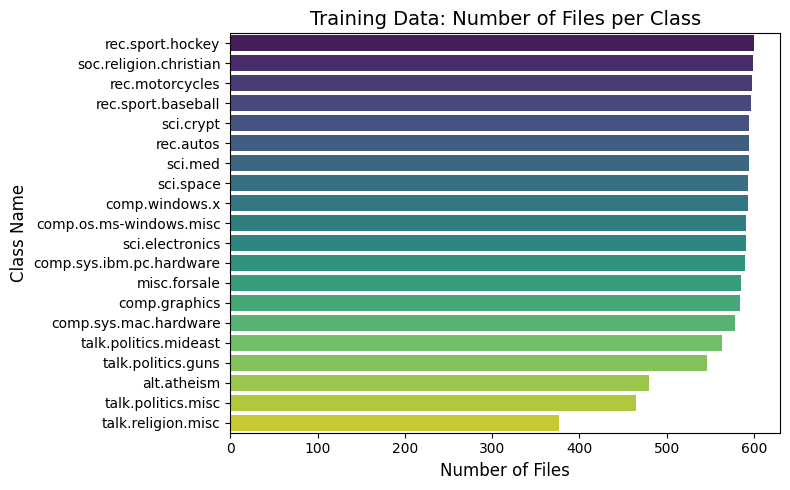

In [5]:
# Count the number of files in each class for the training data
train_class_counts = Counter(y_train)

# Create a bar plot to visualize the file counts per class
sorted_counts = sorted(train_class_counts.items(), key=lambda x: x[1], reverse=True)
classes = [target_names[idx] for idx, _ in sorted_counts]
counts = [count for _, count in sorted_counts]

plt.figure(figsize=(8, 5))
ax = sns.barplot(x=counts, y=classes, hue=classes, palette="viridis", dodge=False)
plt.xlabel("Number of Files", fontsize=12)
plt.ylabel("Class Name", fontsize=12)
plt.title("Training Data: Number of Files per Class", fontsize=14)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()  # Adjust layout so that long class names fit
plt.show()

The data is quite balanced in the most part, However there are some classes("talk.religion.misc" (377 files), "talk.politics.misc" (465 files) and "alt.etheism" (480 files)) that have fewer files compared to the other classes which are around 600 files each. This might lead to higher accuracy on majority classes while underpreforming on minority classes when using Algorithms like Logistic Regression and SVM which optimize a global loss. same thing might happen with kNN and Decision Trees. 
We will see about that later in the project.

## Preprocessing
We can see that our original raw data contains a lot of noise such as punctuation, numbers and special characters. 
As Tf-idf vectorizer will represent the data as a sparse matrix, if we wont remove the noise factors, they will add unnecessary dimensions that do not contribute to meaning and will increase computational cost without meaningful gains.
Also, extra noise can cause models to learn irrelevant patterns, making them less effective.
Another thing is that the data contains stop words(e.g., "the", "is", "and") which are common across all the data, meaning they do not help in distinguishing between categories so keeping them increase noise and will overshadow more meaningful words.

Concluding our wanted Preprocessing steps to execute:
1. Cleaning - Convert text to lowercase (treat "Apple" and "apple" as the same word) and remove punctuation, numbers and special characters.
4. Stopwords Removal - we will filter out common stopwords.
3. Tokenization - Using tf-idf vectorized we will convert the raw data into vectors.
5. Stemming - converting words to their base form, Changing Changed Change will turn into Chang.

In [9]:
import re
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS

def custom_analyzer(text):
    # 1. Cleaning & Lowercasing: Convert text to lowercase and remove non-word characters.
    text = text.lower()
    text = re.sub(r'\W+', ' ', text)
    
    # 2. Tokenization: Tokenize the cleaned text.
    tokens = word_tokenize(text)
    # 3. Stopwords Removal: Filter out common English stopwords.
    tokens = [token for token in tokens if token not in ENGLISH_STOP_WORDS]
    
    # 4. Stemming: Convert tokens to their base form using PorterStemmer.
    stemmer = PorterStemmer()
    stemmed_tokens = [stemmer.stem(token) for token in tokens]
    
    return stemmed_tokens

# Create a TF-IDF Vectorizer with the custom analyzer.
tfidf_vect = TfidfVectorizer(
    analyzer=custom_analyzer,  # use our custom analyzer function
    max_df=0.5,                # ignore terms that appear in more than 50% of the documents
    min_df=5                   # ignore terms that appear in fewer than 5 documents
)

# Fit and transform the training data, then transform the testing data.
X_train_tfidf = tfidf_vect.fit_transform(X_train) # fit - learn the vocabulary and idf, transform - converting documents into document-term matrix
X_test_tfidf = tfidf_vect.transform(X_test) # transform - converting documents into document-term matrix based on the vocabulary and idf learned from the training data

print("TF-IDF vectorized train data shape:", X_train_tfidf.shape)

TF-IDF vectorized train data shape: (11314, 13171)


## Train and Evaluate Multiple Classifiers
We want to see the performance of Logistic regression, Decision Tree, kNN, Naive Bayes and SVM on the data.
In order to do so we will wrap them all in a pipeline to run one by one in an organized way.

In [15]:
# Function to evaluate a classifier and return metrics
def evaluate_classifier(clf, X_train, X_test, y_train, y_test, clf_name):
    start_time = time.time()
    
    # Train the classifier
    clf.fit(X_train, y_train)
    
    # Make predictions
    y_pred = clf.predict(X_test)
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    training_time = time.time() - start_time
    
    return {
        'Classifier': clf_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'Training Time (s)': training_time
    }


# Function to format the results table
def format_results_table(df, groupby='n_components'):
    # Sort the results
    df = df.sort_values(by=[groupby, 'Accuracy'], ascending=[True, False])
    
    # Format the numeric columns
    formatted_df = df.copy()
    formatted_df['Accuracy'] = formatted_df['Accuracy'].map('{:.4f}'.format)
    formatted_df['Precision'] = formatted_df['Precision'].map('{:.4f}'.format)
    formatted_df['Recall'] = formatted_df['Recall'].map('{:.4f}'.format)
    formatted_df['F1-Score'] = formatted_df['F1-Score'].map('{:.4f}'.format)
    # formatted_df['Training Time (s)'] = formatted_df['Training Time (s)'].map('{:.2f}'.format)
    
    if 'Explained Variance' in formatted_df.columns:
        formatted_df['Explained Variance'] = formatted_df['Explained Variance'].map('{:.2%}'.format)
    
    return formatted_df

# Define the classifiers to test
classifiers = [
    ('Decision Tree', DecisionTreeClassifier(random_state=42)),
    ('SVM', LinearSVC(random_state=42, dual=False)),
    ('Logistic Regression', LogisticRegression(random_state=42, max_iter=1000)),
    ('KNN', KNeighborsClassifier(n_neighbors=3)),
    ('Naive Bayes', MultinomialNB())
]

# Store results for each classifier on the original data.
results = []

# First, run the classifiers on the original TF-IDF data (no dimensionality reduction)
print("\n=== Running classifiers on original TF-IDF data (13171 features) ===\n")
for clf_name, clf in classifiers:
    # # Skip Naive Bayes for the original TF-IDF as it requires non-negative features
    # if clf_name == 'Naive Bayes':
    #     continue
    
    try:
        result = evaluate_classifier(clf, X_train_tfidf, X_test_tfidf, y_train, y_test, clf_name)
        result['Dimensions'] = 'Original (No Reduction)'
        result['n_components'] = X_train_tfidf.shape[1]
        results.append(result)
        print(f"Completed: {clf_name} on original TF-IDF data")
    except Exception as e:
        print(f"Error with {clf_name} on original data: {e}")

# Convert the results list to a DataFrame
results_df = pd.DataFrame(results)

# Filter results for original dimensionality
original_results = results_df[results_df['Dimensions'] == 'Original (No Reduction)']

# Display table for original data results without row numbers
print("=== Results for Original TF-IDF Data ===")
print(tabulate(format_results_table(original_results, groupby='n_components'), 
               headers='keys', tablefmt='grid', showindex=False))


=== Running classifiers on original TF-IDF data (13171 features) ===

Completed: Decision Tree on original TF-IDF data
Completed: SVM on original TF-IDF data
Completed: Logistic Regression on original TF-IDF data
Completed: KNN on original TF-IDF data
Completed: Naive Bayes on original TF-IDF data
=== Results for Original TF-IDF Data ===
+---------------------+------------+-------------+----------+------------+---------------------+-------------------------+----------------+
| Classifier          |   Accuracy |   Precision |   Recall |   F1-Score |   Training Time (s) | Dimensions              |   n_components |
+=====================+============+=============+==========+============+=====================+=========================+================+
| Logistic Regression |     0.6837 |      0.6918 |   0.6837 |     0.6828 |           4.2924    | Original (No Reduction) |          13171 |
+---------------------+------------+-------------+----------+------------+---------------------+---

## Dimensionality Reduction
As we know, our training data contains 13171 features(possible terms) in the sparse matrix. Most documents will contain only a small fraction of the possible terms, with most entries being zero.
We want to check if dimension reduction might help us getting rid of less important features that might add noise, prevent overfitting, prevent models from memorizing data patterns that don't generalize, etc. In order to do so we will run the TruncatedSVD with three different values of number of components (100, 200, 300) and see how our classifiers preform for each value. 

In [ ]:
# Define the dimensionality reduction components to test
n_components_list = [900, 1200]

# Run SVD with different n_components values
for n_components in n_components_list:
    print(f"\n=== Running SVD with n_components={n_components} ===\n")
    
    # Create SVD pipeline
    svd_pipeline = make_pipeline(
        TruncatedSVD(n_components=n_components, random_state=42),
        Normalizer(copy=False)
    )
    
    # Apply SVD transformation
    X_train_svd = svd_pipeline.fit_transform(X_train_tfidf)
    X_test_svd = svd_pipeline.transform(X_test_tfidf)
    
    # Get explained variance ratio
    svd = svd_pipeline.named_steps['truncatedsvd']
    explained_variance = svd.explained_variance_ratio_.sum()
    print(f"SVD with {n_components} components explains {explained_variance:.2%} of variance")
    
    # Test each classifier on the reduced data
    for clf_name, clf in classifiers:
        try:
            result = evaluate_classifier(clf, X_train_svd, X_test_svd, y_train, y_test, clf_name)
            result['Dimensions'] = 'SVD'
            result['n_components'] = n_components
            result['Explained Variance'] = explained_variance
            results.append(result)
            print(f"Completed: {clf_name} with n_components={n_components}")
        except Exception as e:
            print(f"Error with {clf_name} on n_components={n_components}: {e}")

# Convert results to DataFrame for better visualization
results_df = pd.DataFrame(results)

# Filter results for SVD dimensionality reduction
svd_results = results_df[results_df['Dimensions'] == 'SVD']

# Display table for SVD reduced data results without row numbers
print("\n=== Results for SVD Reduced Data ===")
print(tabulate(format_results_table(svd_results, groupby='n_components'), 
               headers='keys', tablefmt='grid', showindex=False))

# Display results grouped by dimensionality
print("\n=== RESULTS SUMMARY ===\n")
formatted_results = format_results_table(results_df)
print(tabulate(formatted_results, headers='keys', tablefmt='grid',showindex=False))

# Determine the best classifier for each dimensionality reduction setting
print("\n=== BEST CLASSIFIER FOR EACH DIMENSIONALITY SETTING ===\n")
best_per_dim = results_df.sort_values('Accuracy', ascending=False).drop_duplicates('n_components')
best_formatted = format_results_table(best_per_dim)
print(tabulate(best_formatted, headers='keys', tablefmt='grid'))

# Calculate average performance across dimensionality methods
print("\n=== AVERAGE PERFORMANCE BY CLASSIFIER ===\n")
avg_by_clf = results_df.groupby('Classifier')[['Accuracy', 'Precision', 'Recall', 'F1-Score']].mean().reset_index()
avg_formatted = format_results_table(avg_by_clf, groupby='Classifier')
print(tabulate(avg_formatted, headers='keys', tablefmt='grid'))



=== Running SVD with n_components=900 ===

SVD with 900 components explains 52.50% of variance
Completed: Decision Tree with n_components=900
Completed: SVM with n_components=900
Completed: Logistic Regression with n_components=900
Completed: KNN with n_components=900
Error with Naive Bayes on n_components=900: Negative values in data passed to MultinomialNB (input X).

=== Running SVD with n_components=1200 ===

SVD with 1200 components explains 60.11% of variance
Completed: Decision Tree with n_components=1200
Completed: SVM with n_components=1200
Completed: Logistic Regression with n_components=1200
Completed: KNN with n_components=1200
Error with Naive Bayes on n_components=1200: Negative values in data passed to MultinomialNB (input X).

=== Results for SVD Reduced Data ===
+---------------------+------------+-------------+----------+------------+---------------------+--------------+----------------+----------------------+
| Classifier          |   Accuracy |   Precision |   Reca